# Stage-Aware Transformer Notebook


This notebook provides an end-to-end pipeline for training and evaluating the **Stage-Aware Transformer** model on the **MIMIC-III** dataset for **ICU Mortality Prediction**.

## 1. Imports and seeds


In [16]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
from torch import nn
import torch.nn.utils.rnn as rnn_utils
from torch.utils import data
from torch.autograd import Variable
import torch.nn.functional as F

from utils import utils
from utils.readers import DecompensationReader
from utils.preprocessing import Discretizer, Normalizer
from utils import metrics
from utils import common_utils
from model import StageAwareTransformer

RANDOM_SEED = 1
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True

print("Imports loaded.")
print(f"CUDA available: {torch.cuda.is_available()}")


Imports loaded.
CUDA available: True


## 2. Configuration


In [17]:
# Paths
data_path = './data/'
file_name = 'SAT'
small_part = False

# Training
batch_size = 128
epochs = 50
lr = 1e-3

# Model architecture
input_dim = 76
rnn_dim = 384
output_dim = 1
dropout_rate = 0.5
dropconnect_rate = 0.5
dropres_rate = 0.3
K = 10
chunk_level = 3
num_heads = 8
num_layers = 2
ff_dim = 512
max_len = 512

print(
    f"Config ready | input_dim={input_dim} | rnn_dim={rnn_dim} | "
    f"heads={num_heads} | layers={num_layers}"
)


Config ready | input_dim=76 | rnn_dim=384 | heads=8 | layers=2


## 3. Device


In [18]:
device = torch.device("cuda:0" if torch.cuda.is_available() == True else "cpu")
print(f"available device: {device}")


available device: cuda:0


## 4. Data loading


In [19]:
print('Preparing training data ... ')

train_data_loader = common_utils.DeepSupervisionDataLoader(
    dataset_dir=os.path.join(data_path, 'train'),
    listfile=os.path.join(data_path, 'train_listfile.csv'),
    small_part=small_part
)

val_data_loader = common_utils.DeepSupervisionDataLoader(
    dataset_dir=os.path.join(data_path, 'train'),
    listfile=os.path.join(data_path, 'val_listfile.csv'),
    small_part=small_part
)

test_data_loader = common_utils.DeepSupervisionDataLoader(
    dataset_dir=os.path.join(data_path, 'test'),
    listfile=os.path.join(data_path, 'test_listfile.csv'),
    small_part=small_part
)

print(f"Train samples : {len(train_data_loader._data['X'])}")
print(f"Val   samples : {len(val_data_loader._data['X'])}")
print(f"Test  samples : {len(test_data_loader._data['X'])}")


Preparing training data ... 
Train samples : 35340
Val   samples : 34658
Test  samples : 6237


## 5. Discretizer and normalizer


In [20]:
discretizer = Discretizer(
    timestep=1.0,
    store_masks=True,
    impute_strategy='previous',
    start_time='zero'
)

discretizer_header = discretizer.transform(train_data_loader._data["X"][0])[1].split(',')
cont_channels = [i for (i, x) in enumerate(discretizer_header) if x.find("->") == -1]

normalizer = Normalizer(fields=cont_channels)
normalizer_state = 'decomp_normalizer'
normalizer_state = os.path.join(os.path.dirname(data_path), normalizer_state)
normalizer.load_params(normalizer_state)

print(f"Total features after discretization : {len(discretizer_header)}")
print(f"Continuous channels to normalize    : {len(cont_channels)}")


Total features after discretization : 76
Continuous channels to normalize    : 12


/data/home/sanbav25/Stage-Aware Transformer/utils/preprocessing.py:219: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dct = pickle.load(load_file, encoding='latin1')


## 6. Batch generators


In [21]:
train_data_gen = utils.BatchGenDeepSupervision(
    train_data_loader,
    discretizer,
    normalizer,
    batch_size,
    shuffle=True,
    return_names=True
)

val_data_gen = utils.BatchGenDeepSupervision(
    val_data_loader,
    discretizer,
    normalizer,
    batch_size,
    shuffle=False,
    return_names=True
)

test_data_gen = utils.BatchGenDeepSupervision(
    test_data_loader,
    discretizer,
    normalizer,
    batch_size,
    shuffle=False,
    return_names=True
)

print(f"Train steps per epoch : {train_data_gen.steps}")
print(f"Val   steps per epoch : {val_data_gen.steps}")
print(f"Test  steps           : {test_data_gen.steps}")


Train steps per epoch : 277
Val   steps per epoch : 271
Test  steps           : 49


## 7. Model and optimizer


In [22]:
print('Constructing model ... ')

model = StageAwareTransformer(
    input_dim=input_dim + 17,
    hidden_dim=rnn_dim,
    conv_size=K,
    output_dim=output_dim,
    levels=chunk_level,
    dropconnect=dropconnect_rate,
    dropout=dropout_rate,
    dropres=dropres_rate,
    num_heads=num_heads,
    num_layers=num_layers,
    ff_dim=ff_dim,
    max_len=max_len,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model: StageAwareTransformer")
print(f"Trainable parameters: {total_params:,}")


Constructing model ... 
Model: StageAwareTransformer
Trainable parameters: 3,486,593


/data/home/sanbav25/StageNet-master/StageNet-master/venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 8. Helper for interval features


In [23]:
def build_interval_tensor(x_tensor):
    tmp = torch.zeros(x_tensor.size(0), 17, dtype=torch.float32).to(device)
    interval = torch.zeros((x_tensor.size(0), x_tensor.size(1), 17), dtype=torch.float32).to(device)

    for i in range(x_tensor.size(1)):
        cur_ind = x_tensor[:, i, -17:]
        tmp += (cur_ind == 0).float()
        interval[:, i, :] = cur_ind * tmp
        tmp[cur_ind == 1] = 0

    return interval

print("Helper ready.")


Helper ready.


## 9. Training loop


In [11]:
train_loss = []
val_loss = []
batch_loss = []
max_auprc = 0
saved_model_path = './saved_weights/' + file_name

print('Start training ... ')

for each_chunk in range(epochs):
    cur_batch_loss = []
    model.train()

    for each_batch in range(train_data_gen.steps):
        batch_data = next(train_data_gen)
        batch_name = batch_data['names']
        batch_data = batch_data['data']

        batch_x = torch.tensor(batch_data[0][0], dtype=torch.float32).to(device)
        batch_mask = torch.tensor(batch_data[0][1], dtype=torch.float32).unsqueeze(-1).to(device)
        batch_y = torch.tensor(batch_data[1], dtype=torch.float32).to(device)
        batch_interval = build_interval_tensor(batch_x)

        if batch_mask.size()[1] > 400:
            batch_x = batch_x[:, :400, :]
            batch_mask = batch_mask[:, :400, :]
            batch_y = batch_y[:, :400, :]
            batch_interval = batch_interval[:, :400, :]

        batch_x = torch.cat((batch_x, batch_interval), dim=-1)
        batch_time = torch.ones((batch_x.size(0), batch_x.size(1)), dtype=torch.float32).to(device)

        optimizer.zero_grad()
        cur_output, _ = model(batch_x, batch_time, device)
        masked_output = cur_output * batch_mask

        loss = batch_y * torch.log(masked_output + 1e-7) + (1 - batch_y) * torch.log(1 - masked_output + 1e-7)
        loss = torch.sum(loss, dim=1) / torch.sum(batch_mask, dim=1)
        loss = torch.neg(torch.sum(loss))
        cur_batch_loss.append(loss.cpu().detach().numpy())

        loss.backward()
        optimizer.step()

        if each_batch % 50 == 0:
            print('Chunk %d, Batch %d: Loss = %.4f' % (each_chunk, each_batch, cur_batch_loss[-1]))

    batch_loss.append(cur_batch_loss)
    train_loss.append(np.mean(np.array(cur_batch_loss)))

    print("\n==>Predicting on validation")
    with torch.no_grad():
        model.eval()
        cur_val_loss = []
        valid_true = []
        valid_pred = []

        for each_batch in range(val_data_gen.steps):
            valid_data = next(val_data_gen)
            valid_name = valid_data['names']
            valid_data = valid_data['data']

            valid_x = torch.tensor(valid_data[0][0], dtype=torch.float32).to(device)
            valid_mask = torch.tensor(valid_data[0][1], dtype=torch.float32).unsqueeze(-1).to(device)
            valid_y = torch.tensor(valid_data[1], dtype=torch.float32).to(device)
            valid_interval = build_interval_tensor(valid_x)

            if valid_mask.size()[1] > 400:
                valid_x = valid_x[:, :400, :]
                valid_mask = valid_mask[:, :400, :]
                valid_y = valid_y[:, :400, :]
                valid_interval = valid_interval[:, :400, :]

            valid_x = torch.cat((valid_x, valid_interval), dim=-1)
            valid_time = torch.ones((valid_x.size(0), valid_x.size(1)), dtype=torch.float32).to(device)

            valid_output, valid_dis = model(valid_x, valid_time, device)
            masked_valid_output = valid_output * valid_mask

            valid_loss = valid_y * torch.log(masked_valid_output + 1e-7) + (1 - valid_y) * torch.log(1 - masked_valid_output + 1e-7)
            valid_loss = torch.sum(valid_loss, dim=1) / torch.sum(valid_mask, dim=1)
            valid_loss = torch.neg(torch.sum(valid_loss))
            cur_val_loss.append(valid_loss.cpu().detach().numpy())

            for m, t, p in zip(valid_mask.cpu().numpy().flatten(), valid_y.cpu().numpy().flatten(), valid_output.cpu().detach().numpy().flatten()):
                if np.equal(m, 1):
                    valid_true.append(t)
                    valid_pred.append(p)

        val_loss.append(np.mean(np.array(cur_val_loss)))
        print('Valid loss = %.4f' % (val_loss[-1]))
        print('\n')
        valid_pred = np.array(valid_pred)
        valid_pred = np.stack([1 - valid_pred, valid_pred], axis=1)
        ret = metrics.print_metrics_binary(valid_true, valid_pred)
        print()

        cur_auprc = ret['auprc']
        if cur_auprc > max_auprc:
            max_auprc = cur_auprc
            state = {
                'net': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'chunk': each_chunk
            }
            torch.save(state, saved_model_path)
            print('\n------------ Save best model ------------\n')


Start training ... 
Chunk 0, Batch 0: Loss = 91.4618
Chunk 0, Batch 50: Loss = 17.6739
Chunk 0, Batch 100: Loss = 17.3732
Chunk 0, Batch 150: Loss = 21.6728
Chunk 0, Batch 200: Loss = 15.7003
Chunk 0, Batch 250: Loss = 9.9974

==>Predicting on validation
Valid loss = 12.2993


confusion matrix:
[[411612   5608]
 [  7355   1704]]
accuracy = 0.9695903658866882
precision class 0 = 0.9824449419975281
precision class 1 = 0.23304156959056854
recall class 0 = 0.9865586757659912
recall class 1 = 0.18810023367404938
AUC of ROC = 0.8728017359410992
AUC of PRC = 0.15689932582517482
min(+P, Se) = 0.2234359483614697


------------ Save best model ------------

Chunk 1, Batch 0: Loss = 13.8966
Chunk 1, Batch 50: Loss = 9.8669
Chunk 1, Batch 100: Loss = 10.0205
Chunk 1, Batch 150: Loss = 17.4272
Chunk 1, Batch 200: Loss = 14.3144
Chunk 1, Batch 250: Loss = 14.1533

==>Predicting on validation
Valid loss = 13.3072


confusion matrix:
[[402088  15132]
 [  5339   3720]]
accuracy = 0.9519774317741394
pre

## 10. Final evaluation on test set


available device: cuda:0
Preparing test data ... 


/data/home/sanbav25/Stage-Aware Transformer/utils/preprocessing.py:219: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dct = pickle.load(load_file, encoding='latin1')


Constructing model ... 
Testing model ... 
last saved model is in chunk 33


/data/home/sanbav25/StageNet-master/StageNet-master/venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Test loss = 9.7969


confusion matrix:
[[464048   2431]
 [  6238   2765]]
accuracy = 0.9817679524421692
precision class 0 = 0.9867357015609741
precision class 1 = 0.5321401357650757
recall class 0 = 0.994788646697998
recall class 1 = 0.30711984634399414
AUC of ROC = 0.9129761087145161
AUC of PRC = 0.3919878618372861
min(+P, Se) = 0.402088192824614
AUROC = 0.9130


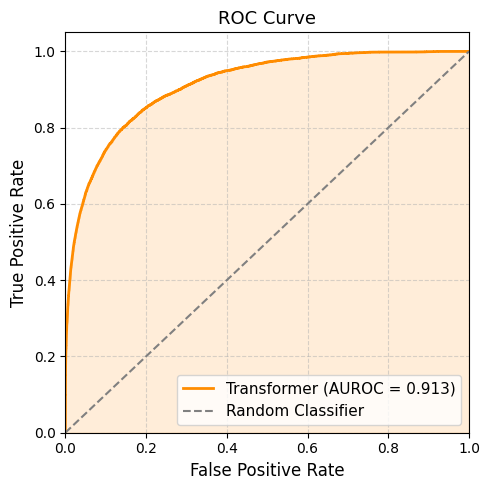

In [ ]:
import os
import numpy as np
import torch
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ========= config =========
RANDOM_SEED = 1
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("available device:", device)


ckpt_path = './saved_weights/checkpoint'

# ========= prepare test data =========
print('Preparing test data ... ')

train_data_loader = common_utils.DeepSupervisionDataLoader(
    dataset_dir=os.path.join(data_path, 'train'),
    listfile=os.path.join(data_path, 'train_listfile.csv'),
    small_part=True
)

discretizer = Discretizer(
    timestep=1.0,
    store_masks=True,
    impute_strategy='previous',
    start_time='zero'
)

discretizer_header = discretizer.transform(train_data_loader._data["X"][0])[1].split(',')
cont_channels = [i for (i, x) in enumerate(discretizer_header) if x.find("->") == -1]

normalizer = Normalizer(fields=cont_channels)
normalizer_state = 'decomp_normalizer'
normalizer_state = os.path.join(os.path.dirname(data_path), normalizer_state)
normalizer.load_params(normalizer_state)

test_data_loader = common_utils.DeepSupervisionDataLoader(
    dataset_dir=os.path.join(data_path, 'test'),
    listfile=os.path.join(data_path, 'test_listfile.csv'),
    small_part=small_part
)

test_data_gen = utils.BatchGenDeepSupervision(
    test_data_loader,
    discretizer,
    normalizer,
    batch_size,
    shuffle=False,
    return_names=True
)

# ========= construct model =========
print('Constructing model ... ')

model = StageAwareTransformer(
    input_dim=76 + 17,
    hidden_dim=384,
    conv_size=10,
    output_dim=1,
    levels=3,
    dropconnect=0.3,
    dropout=0.3,
    dropres=0.3,
    num_heads=8,
    num_layers=2,
    ff_dim=512,
    max_len=512,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# ========= load checkpoint =========
print('Testing model ... ')

checkpoint = torch.load(ckpt_path, map_location=device)
save_chunk = checkpoint['chunk']
print("last saved model is in chunk {}".format(save_chunk))

model.load_state_dict(checkpoint['net'])
optimizer.load_state_dict(checkpoint['optimizer'])
model.eval()

# ========= test loop =========
with torch.no_grad():
    cur_test_loss = []
    test_true = []
    test_pred = []

    for each_batch in range(test_data_gen.steps):
        test_data = next(test_data_gen)
        test_name = test_data['names']
        test_data = test_data['data']

        test_x = torch.tensor(test_data[0][0], dtype=torch.float32).to(device)
        test_mask = torch.tensor(test_data[0][1], dtype=torch.float32).unsqueeze(-1).to(device)
        test_y = torch.tensor(test_data[1], dtype=torch.float32).to(device)

        tmp = torch.zeros(test_x.size(0), 17, dtype=torch.float32).to(device)
        test_interval = torch.zeros((test_x.size(0), test_x.size(1), 17), dtype=torch.float32).to(device)

        for i in range(test_x.size(1)):
            cur_ind = test_x[:, i, -17:]
            tmp += (cur_ind == 0).float()
            test_interval[:, i, :] = cur_ind * tmp
            tmp[cur_ind == 1] = 0

        if test_mask.size()[1] > 400:
            test_x = test_x[:, :400, :]
            test_mask = test_mask[:, :400, :]
            test_y = test_y[:, :400, :]
            test_interval = test_interval[:, :400, :]

        test_x = torch.cat((test_x, test_interval), dim=-1)
        test_time = torch.ones((test_x.size(0), test_x.size(1)), dtype=torch.float32).to(device)

        test_output, test_dis = model(test_x, test_time, device)
        masked_test_output = test_output * test_mask

        test_loss = test_y * torch.log(masked_test_output + 1e-7) + \
                    (1 - test_y) * torch.log(1 - masked_test_output + 1e-7)
        test_loss = torch.sum(test_loss, dim=1) / torch.sum(test_mask, dim=1)
        test_loss = torch.neg(torch.sum(test_loss))
        cur_test_loss.append(test_loss.cpu().detach().numpy())

        for m, t, p in zip(
            test_mask.cpu().numpy().flatten(),
            test_y.cpu().numpy().flatten(),
            test_output.cpu().detach().numpy().flatten()
        ):
            if np.equal(m, 1):
                test_true.append(t)
                test_pred.append(p)

    print('Test loss = %.4f' % (np.mean(np.array(cur_test_loss))))
    print('\n')

    test_pred = np.array(test_pred)
    test_pred = np.stack([1 - test_pred, test_pred], axis=1)

    test_ret = metrics.print_metrics_binary(test_true, test_pred)

    test_pred_prob = test_pred[:, 1]
    fpr, tpr, _ = roc_curve(test_true, test_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 5))
    plt.fill_between(fpr, tpr, alpha=0.15, color='darkorange')
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Transformer (AUROC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve', fontsize=13)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('roc_curve.pdf', format='pdf', dpi=300)

    print(f'AUROC = {roc_auc:.4f}')